![орп](xi_test.png)
1. Начнем с проверки простой гипотезы.
Найдите первые 1000 цифр числа π после запятой. С помощью критерия хи-квадрат проверьте,
можно ли при уровне значимости 0.05 считать эти цифры случайными равномерными?

1000
[0.093 0.116 0.103 0.102 0.093 0.097 0.094 0.095 0.101 0.106]
статистика при H0 = 4.739999999999999, квантиль уровня 1 - alpha = 16.918977604620448
Гипотезу принимаем


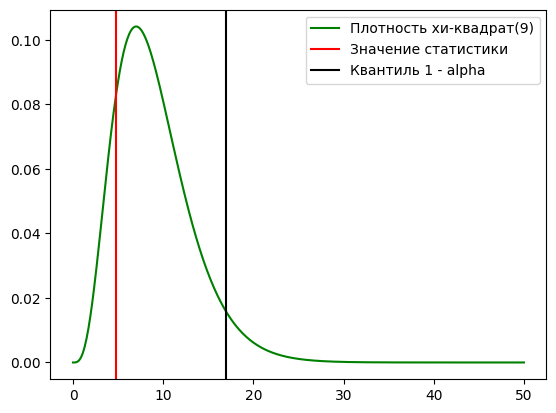

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from mpmath import mp #для пи
mp.dps = 1001
#H0: первые 1000 цифр равномерны на {0,...,9}, т.е. каждое встречается с вероятностью 1/10
#H1: не H0
#План такой - посчитать статистику при H0, если она окажется больше чем квантиль 0.05 распределения, к которому она стремится, то отвергаем, если нет - принимаем
def yest_a_hypothesis(alpha, n, p):
    pi_str = str(mp.pi)[2:1003]
    quantity = np.array([0] * 10) #массив для абсолютных частот, они в формуле нюi
    for digit in pi_str:
        i = int(digit)
        quantity[i] += 1
    print(np.sum(quantity))
    frequency = quantity / n 
    print(frequency)#это относительные чатоты, ожидаемые все равны 0.1
    statistic = np.sum(((quantity - n * p)**2) / (n * p)) #должна стремиться к хи-квадрат (n-1)
    #ppf = Percent Point Function = Обратная функция распределения = квантиль
    alphath_quantile = stats.chi2.ppf(1 - alpha, df = 9) # df - степени свободы, хотим чтобы P(statistic < q_1-alpha) = 1 - alpha при H0
    print(f"статистика при H0 = {statistic}, квантиль уровня 1 - alpha = {alphath_quantile}")
    if statistic > alphath_quantile:
        print(f"Гипотезу отвергаем")
    else:
        print(f"Гипотезу принимаем")
    x = np.linspace(0, 50, 500)
    y = stats.chi2.pdf(x, df=9)
    plt.plot(x, y, color = 'green', label = "Плотность хи-квадрат(9)")
    plt.axvline(statistic, color = 'red', label = 'Значение статистики')
    plt.axvline(alphath_quantile, color = 'black', label = 'Квантиль 1 - alpha')
    plt.legend()
    plt.show()
        
alpha = 0.05
n = 1000
p = 0.1
yest_a_hypothesis(alpha, n, p)        
    

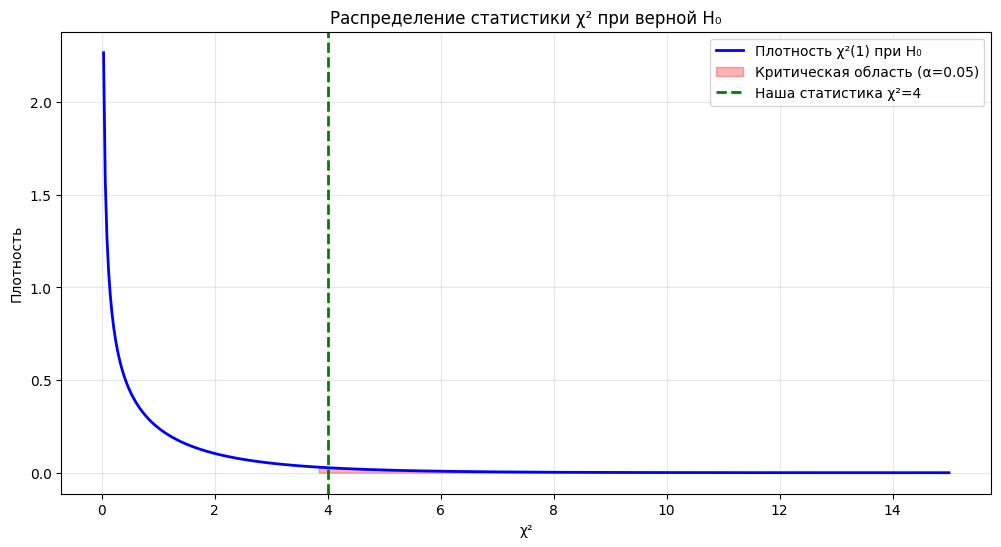

Вероятность получить χ² > 3.84 при H₀ = 0.050
Вероятность получить χ² > 4.00 при H₀ = 0.046
Вероятность получить χ² > 0.50 при H₀ = 0.480


In [18]:
#Для понимания как работает критерий хи-квадрат
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Создаем график
x = np.linspace(0, 15, 500)
y = stats.chi2.pdf(x, df=1)

plt.figure(figsize=(12, 6))
plt.plot(x, y, 'b-', linewidth=2, label='Плотность χ²(1) при H₀')

# Критическая область
x_crit = np.linspace(3.84, 15, 100)
y_crit = stats.chi2.pdf(x_crit, df=1)
plt.fill_between(x_crit, y_crit, alpha=0.3, color='red', label='Критическая область (α=0.05)')

# Наша статистика
plt.axvline(x=4, color='green', linewidth=2, linestyle='--', label='Наша статистика χ²=4')

plt.xlabel('χ²')
plt.ylabel('Плотность')
plt.title('Распределение статистики χ² при верной H₀')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Посчитаем вероятности
print(f"Вероятность получить χ² > 3.84 при H₀ = {1 - stats.chi2.cdf(3.84, df=1):.3f}")
print(f"Вероятность получить χ² > 4.00 при H₀ = {1 - stats.chi2.cdf(4.00, df=1):.3f}")
print(f"Вероятность получить χ² > 0.50 при H₀ = {1 - stats.chi2.cdf(0.50, df=1):.3f}")

2. Проверим однородность и независимость. Использовать данные из файла Priem.csv и встроенный
критерий.

(a) Ответить на вопрос - отличаются ли мальчики и девочки в плане успешности сдачи ЕГЭ?
Для этого попарно проверьте на однородность суммарные баллы, баллы по русскому, баллы
по математике.

(b) Правда ли, что оценки по математике и русскому независимы?

В статистике проверка однородности (или тест на однородность) используется для того, чтобы ответить на вопрос: «Взяты ли две (или более) выборки из одного и того же распределения?» Или, другими словами: «Есть ли статистически значимые различия между двумя группами по интересующему нас признаку?»

В нашем случае признак — успешность сдачи ЕГЭ, а группы — мальчики и девочки.

Мы выдвигаем две гипотезы:

H₀ (Нулевая гипотеза): Распределение успешности сдачи ЕГЭ у мальчиков и девочек одинаково (однородно). Различия между ними случайны.

H₁ (Альтернативная гипотеза): Распределения различаются. Успешность зависит от пола.

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv('Priem.csv', encoding='cp1251')
print("Колонки в файле:", df.columns.tolist())


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xcf in position 1: invalid continuation byte